#  BYOL Downstream (Decoder Attachment + Fine-tuning)
### CSE 438 Part B — SSL for Semantic Segmentation



In [1]:
import json
import torch
import torch.nn as nn
import pandas as pd
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
CONFIG = {
    "method": "BYOL",
    "num_classes": 24,
    "image_size": 512,
    "encoder_out_channels": 2048,
    "freeze_encoder": True,
    "encoder_checkpoint": "/kaggle/input/notebooks/mashrur135/nb-byol/byol_encoder_checkpoint.pth",
}
print(json.dumps(CONFIG, indent=2))


{
  "method": "BYOL",
  "num_classes": 24,
  "image_size": 512,
  "encoder_out_channels": 2048,
  "freeze_encoder": true,
  "encoder_checkpoint": "/kaggle/input/notebooks/mashrur135/nb-byol/byol_encoder_checkpoint.pth"
}


## Re-declare the BYOL online encoder's backbone

In [3]:
class BYOLEncoder(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        resnet = models.resnet50(weights="IMAGENET1K_V2" if pretrained else None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # -> [B, 2048, H, W]

    def forward(self, x):
        return self.backbone(x)


encoder = BYOLEncoder(pretrained=False).to(DEVICE)

checkpoint = torch.load(CONFIG["encoder_checkpoint"], map_location=DEVICE)
encoder.backbone.load_state_dict(checkpoint["backbone_state_dict"])
print(f"Loaded BYOL encoder, pretrained for {checkpoint['config']['pretrain_epochs']} epochs,")
print(f"final BYOL loss: {checkpoint['final_loss']:.4f}")


Loaded BYOL encoder, pretrained for 50 epochs,
final BYOL loss: 0.4134


## Decoder — same borrowed ASPP head as SimCLR's notebook

In [4]:
_deeplab_full = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
_deeplab_full.classifier[4] = nn.Conv2d(256, CONFIG["num_classes"], kernel_size=1)

decoder = _deeplab_full.classifier
del _deeplab_full

decoder = decoder.to(DEVICE)
print(decoder)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 230MB/s]


DeepLabHead(
  (0): ASPP(
    (convs): ModuleList(
      (0): Sequential(
        (0): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (1): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(12, 12), dilation=(12, 12), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (2): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(24, 24), dilation=(24, 24), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (3): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(36, 36), dilation=(36, 36), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

In [5]:
class SegmentationModel(nn.Module):
    def __init__(self, encoder, decoder, image_size, freeze_encoder=True):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.image_size = image_size
        self.set_encoder_frozen(freeze_encoder)

    def set_encoder_frozen(self, freeze):
        for p in self.encoder.parameters():
            p.requires_grad = not freeze
        self.encoder.train(not freeze)

    def forward(self, x):
        if not any(p.requires_grad for p in self.encoder.parameters()):
            with torch.no_grad():
                features = self.encoder(x)
        else:
            features = self.encoder(x)
        logits = self.decoder(features)
        logits = F.interpolate(logits, size=(self.image_size, self.image_size),
                                mode="bilinear", align_corners=False)
        return logits


model = SegmentationModel(encoder, decoder, CONFIG["image_size"],
                           freeze_encoder=CONFIG["freeze_encoder"]).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({'frozen encoder' if CONFIG['freeze_encoder'] else 'fine-tuned encoder'})")


Trainable params: 16,131,608 / 39,639,640 (frozen encoder)


## Shape check with a dummy tensor

In [6]:
with torch.no_grad():
    dummy = torch.randn(2, 3, CONFIG["image_size"], CONFIG["image_size"]).to(DEVICE)
    out = model(dummy)
    print(f"Input:  {dummy.shape}")
    print(f"Output: {out.shape}")
    assert out.shape == (2, CONFIG["num_classes"], CONFIG["image_size"], CONFIG["image_size"])
    print("Shape check passed ✅ -- ready for Task D.")


Input:  torch.Size([2, 3, 512, 512])
Output: torch.Size([2, 24, 512, 512])
Shape check passed ✅ -- ready for Task D.


---
# Task D — Supervised Fine-tuning


In [7]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

DATA_PREP_DIR = "/kaggle/input/notebooks/mashrur135/nb-01-data-prep/artifacts/splits"

valid_df = pd.read_csv(f"{DATA_PREP_DIR}/valid_split.csv")
test_df  = pd.read_csv(f"{DATA_PREP_DIR}/test_split.csv")

print(f"Validation (labelled fine-tuning set): {len(valid_df)} images")
print(f"Test (monitoring + final eval):        {len(test_df)} images")


Validation (labelled fine-tuning set): 60 images
Test (monitoring + final eval):        60 images


## Fine-tuning config

In [8]:
FT_CONFIG = {
    "finetune_epochs": 50,
    "batch_size": 8,
    "encoder_lr": 1e-5,     # small LR for the pretrained encoder (only used if NOT frozen)
    "decoder_lr": 1e-4,     # larger LR for the decoder + adapter (always trained from scratch here)
    "optimizer": "AdamW",
    "weight_decay": 1e-4,
    "scheduler": "ReduceLROnPlateau",
}
print(json.dumps(FT_CONFIG, indent=2))


{
  "finetune_epochs": 50,
  "batch_size": 8,
  "encoder_lr": 1e-05,
  "decoder_lr": 0.0001,
  "optimizer": "AdamW",
  "weight_decay": 0.0001,
  "scheduler": "ReduceLROnPlateau"
}


## Fine-tuning transforms + Dataset



In [9]:
def read_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return mask

finetune_transform = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.Normalize(),
    ToTensorV2(),
])


class SegDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
        mask = read_mask(row["mask_path"])
        out = self.transform(image=image, mask=mask)
        return out["image"], out["mask"].long()


valid_dataset = SegDataset(valid_df, finetune_transform)
test_dataset  = SegDataset(test_df, eval_transform)

valid_loader = DataLoader(valid_dataset, batch_size=FT_CONFIG["batch_size"], shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=FT_CONFIG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)

print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches:       {len(test_loader)}")


Validation batches: 8
Test batches:       8


## Class weights from the validation split's pixel distribution

In [10]:
pixel_counts = Counter()
for mask_path in valid_df["mask_path"]:
    mask = read_mask(mask_path)
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        pixel_counts[int(u)] += int(c)

class_pixel_counts = np.array([pixel_counts.get(c, 0) for c in range(CONFIG["num_classes"])], dtype=np.float64)
epsilon = 1.0
inverse_freq = 1.0 / (class_pixel_counts + epsilon)
class_weights = inverse_freq / inverse_freq.mean()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights computed from validation-split pixel distribution.")


Class weights computed from validation-split pixel distribution.


## Metric functions 

In [11]:
def per_class_iou(preds, masks, num_classes):
    preds = preds.reshape(-1); masks = masks.reshape(-1)
    ious = []
    for cls in range(num_classes):
        pred_cls, mask_cls = preds == cls, masks == cls
        intersection = (pred_cls & mask_cls).sum().item()
        union = (pred_cls | mask_cls).sum().item()
        ious.append(float("nan") if union == 0 else intersection / union)
    return ious

def mean_iou(preds, masks, num_classes):
    return float(np.nanmean(per_class_iou(preds, masks, num_classes)))

def pixel_accuracy(preds, masks):
    return (preds == masks).sum().item() / masks.numel()

def dice_score(preds, masks, num_classes):
    scores = []
    for cls in range(num_classes):
        pred_cls, gt_cls = preds == cls, masks == cls
        intersection = (pred_cls & gt_cls).sum().item()
        denom = pred_cls.sum().item() + gt_cls.sum().item()
        if denom == 0: continue
        scores.append((2 * intersection) / denom)
    return float(np.mean(scores))


## Optimizer 

In [12]:
param_groups = [{"params": model.decoder.parameters(), "lr": FT_CONFIG["decoder_lr"]}]
if hasattr(model, "adapter"):
    param_groups.append({"params": model.adapter.parameters(), "lr": FT_CONFIG["decoder_lr"]})
if not CONFIG["freeze_encoder"]:
    param_groups.append({"params": model.encoder.parameters(), "lr": FT_CONFIG["encoder_lr"]})

optimizer = torch.optim.AdamW(param_groups, weight_decay=FT_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Optimizer set up with {len(param_groups)} param group(s).")


Optimizer set up with 1 param group(s).


## Training loop

In [13]:
train_losses, valid_losses_monitor, monitor_mious = [], [], []
best_miou = 0.0
best_ckpt_path = f"/kaggle/working/{CONFIG['method'].lower()}_best_finetuned.pth"

finetune_start = time.time()

for epoch in range(FT_CONFIG["finetune_epochs"]):
    t0 = time.time()

    # ---- Fine-tune on validation split (labelled data) ----
    model.train()
    if CONFIG["freeze_encoder"]:
        model.encoder.eval()   # keep frozen encoder's BatchNorm/dropout in eval mode
    running_loss = 0.0

    for images, masks in valid_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(valid_loader)
    train_losses.append(avg_train_loss)

    # ---- Monitor on test split (checkpoint selection signal) ----
    model.eval()
    monitor_loss, monitor_iou = 0.0, []
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, masks)
            monitor_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            monitor_iou.append(mean_iou(preds.cpu(), masks.cpu(), CONFIG["num_classes"]))

    avg_monitor_loss = monitor_loss / len(test_loader)
    avg_monitor_miou = float(np.nanmean(monitor_iou))
    valid_losses_monitor.append(avg_monitor_loss)
    monitor_mious.append(avg_monitor_miou)

    scheduler.step(avg_monitor_miou)

    if avg_monitor_miou > best_miou:
        best_miou = avg_monitor_miou
        torch.save({
            "model_state_dict": model.state_dict(),
            "config": CONFIG,
            "ft_config": FT_CONFIG,
            "epoch": epoch + 1,
            "monitor_miou": best_miou,
        }, best_ckpt_path)

    epoch_time = time.time() - t0
    print(f"Epoch {epoch+1}/{FT_CONFIG['finetune_epochs']} | "
          f"train_loss: {avg_train_loss:.4f} | monitor_loss: {avg_monitor_loss:.4f} | "
          f"monitor_mIoU: {avg_monitor_miou:.4f} | time: {epoch_time:.1f}s")

finetune_time = time.time() - finetune_start
print(f"\nFine-tuning complete. Best monitor mIoU: {best_miou:.4f}, saved to {best_ckpt_path}")
print(f"Total fine-tuning time: {finetune_time/60:.1f} min ({finetune_time/FT_CONFIG['finetune_epochs']:.1f}s/epoch avg)")


Epoch 1/50 | train_loss: 3.1378 | monitor_loss: 3.0625 | monitor_mIoU: 0.0322 | time: 30.0s
Epoch 2/50 | train_loss: 2.9547 | monitor_loss: 2.9735 | monitor_mIoU: 0.0445 | time: 28.5s
Epoch 3/50 | train_loss: 2.8058 | monitor_loss: 2.8860 | monitor_mIoU: 0.0627 | time: 26.2s
Epoch 4/50 | train_loss: 2.6653 | monitor_loss: 2.7949 | monitor_mIoU: 0.0771 | time: 28.1s
Epoch 5/50 | train_loss: 2.5551 | monitor_loss: 2.6960 | monitor_mIoU: 0.0826 | time: 26.1s
Epoch 6/50 | train_loss: 2.4435 | monitor_loss: 2.6265 | monitor_mIoU: 0.0913 | time: 26.1s
Epoch 7/50 | train_loss: 2.2995 | monitor_loss: 2.5489 | monitor_mIoU: 0.0921 | time: 26.2s
Epoch 8/50 | train_loss: 2.1794 | monitor_loss: 2.5067 | monitor_mIoU: 0.0876 | time: 26.1s
Epoch 9/50 | train_loss: 2.0807 | monitor_loss: 2.4386 | monitor_mIoU: 0.0923 | time: 26.9s
Epoch 10/50 | train_loss: 2.0375 | monitor_loss: 2.4103 | monitor_mIoU: 0.0989 | time: 26.6s
Epoch 11/50 | train_loss: 1.9085 | monitor_loss: 2.3708 | monitor_mIoU: 0.1062 

## Fine-tuning curves 

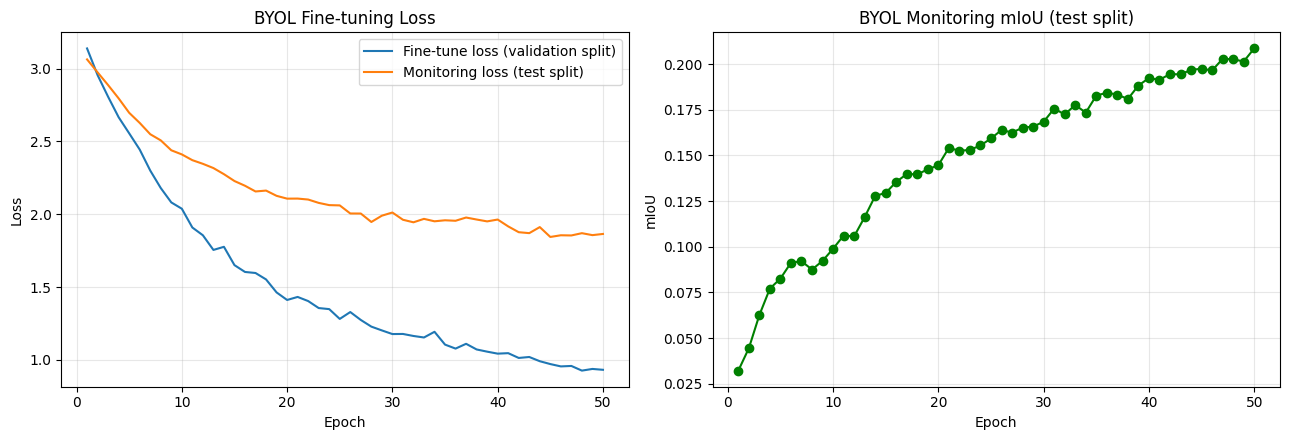

In [14]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, train_losses, label="Fine-tune loss (validation split)")
axes[0].plot(epochs_range, valid_losses_monitor, label="Monitoring loss (test split)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"{CONFIG['method']} Fine-tuning Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, monitor_mious, marker="o", color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mIoU")
axes[1].set_title(f"{CONFIG['method']} Monitoring mIoU (test split)"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_finetune_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Save summary 

In [15]:
finetune_summary = {
    "method": CONFIG["method"],
    "freeze_encoder": CONFIG["freeze_encoder"],
    "finetune_epochs": FT_CONFIG["finetune_epochs"],
    "final_epoch_50_mIoU": monitor_mious[-1],
    "best_monitor_mIoU": best_miou,
    "finetune_time_minutes": finetune_time / 60,
    "labelled_images_used": len(valid_df),
    "best_checkpoint_path": best_ckpt_path,
}

with open(f"/kaggle/working/{CONFIG['method'].lower()}_finetune_summary.json", "w") as f:
    json.dump(finetune_summary, f, indent=2)

print(json.dumps(finetune_summary, indent=2))
print("\nNext: Task E loads best_ckpt_path, evaluates on test_loader one final time for reported metrics,")
print("then Task F does error analysis on the worst-performing test images.")


{
  "method": "BYOL",
  "freeze_encoder": true,
  "finetune_epochs": 50,
  "final_epoch_50_mIoU": 0.20857206149570612,
  "best_monitor_mIoU": 0.20857206149570612,
  "finetune_time_minutes": 22.129608269532522,
  "labelled_images_used": 60,
  "best_checkpoint_path": "/kaggle/working/byol_best_finetuned.pth"
}

Next: Task E loads best_ckpt_path, evaluates on test_loader one final time for reported metrics,
then Task F does error analysis on the worst-performing test images.


---
# Task E — Testing, Metrics & Label-Efficiency Comparison


In [16]:
best_checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}, "
      f"monitor mIoU at save time: {best_checkpoint['monitor_miou']:.4f}")


Loaded best checkpoint from epoch 50, monitor mIoU at save time: 0.2086


## Full confusion matrix + per-image IoU tracking

In [17]:
def update_confusion_matrix(conf_mat, preds, masks, num_classes):
    preds = preds.reshape(-1); masks = masks.reshape(-1)
    valid = (masks >= 0) & (masks < num_classes)
    idx = num_classes * masks[valid] + preds[valid]
    conf_mat += torch.bincount(idx, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return conf_mat


num_classes = CONFIG["num_classes"]
confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.long)

per_image_records = []   # (image_path, mask_path, per-image mIoU) for Task F

all_test_paths = test_df[["image_path", "mask_path"]].reset_index(drop=True)
running_idx = 0

with torch.no_grad():
    for images, masks in test_loader:
        images_gpu, masks_gpu = images.to(DEVICE), masks.to(DEVICE)
        logits = model(images_gpu)
        preds = torch.argmax(logits, dim=1)

        confusion_matrix = update_confusion_matrix(confusion_matrix, preds.cpu(), masks_gpu.cpu(), num_classes)

        for i in range(images.shape[0]):
            img_iou = mean_iou(preds[i].cpu(), masks_gpu[i].cpu(), num_classes)
            row = all_test_paths.iloc[running_idx]
            per_image_records.append({
                "image_path": row["image_path"],
                "mask_path": row["mask_path"],
                "iou": img_iou,
            })
            running_idx += 1

print(f"Evaluated {running_idx} test images.")


Evaluated 60 test images.


## Compute final metrics from the confusion matrix

In [18]:
def metrics_from_confusion(conf_mat):
    conf_mat = conf_mat.float()
    tp = torch.diag(conf_mat)
    fp = conf_mat.sum(dim=0) - tp
    fn = conf_mat.sum(dim=1) - tp

    union = tp + fp + fn
    per_class_iou_final = torch.where(union > 0, tp / union, torch.tensor(float("nan")))
    per_class_dice = torch.where((2*tp+fp+fn) > 0, 2*tp / (2*tp + fp + fn), torch.tensor(float("nan")))

    pixel_acc = tp.sum() / conf_mat.sum()
    return per_class_iou_final, per_class_dice, pixel_acc


final_per_class_iou, final_per_class_dice, final_pixel_acc = metrics_from_confusion(confusion_matrix)
final_miou = float(np.nanmean(final_per_class_iou.numpy()))
final_dice = float(np.nanmean(final_per_class_dice.numpy()))

print(f"=== {CONFIG['method']} — Final Test-Set Metrics ===")
print(f"mIoU:          {final_miou:.4f}")
print(f"Mean Dice:     {final_dice:.4f}")
print(f"Pixel Accuracy:{final_pixel_acc:.4f}")
print(f"\nPer-class IoU:")
for c in range(num_classes):
    val = final_per_class_iou[c].item()
    print(f"  Class {c}: {val:.4f}" if not np.isnan(val) else f"  Class {c}: (not present in test set)")


=== BYOL — Final Test-Set Metrics ===
mIoU:          0.2497
Mean Dice:     0.3643
Pixel Accuracy:0.5788

Per-class IoU:
  Class 0: 0.0151
  Class 1: 0.5403
  Class 2: 0.2017
  Class 3: 0.6997
  Class 4: 0.3784
  Class 5: 0.6184
  Class 6: 0.1391
  Class 7: 0.2845
  Class 8: 0.2590
  Class 9: 0.5718
  Class 10: 0.1359
  Class 11: 0.1376
  Class 12: 0.0773
  Class 13: 0.0672
  Class 14: 0.0410
  Class 15: 0.1773
  Class 16: 0.0291
  Class 17: 0.4512
  Class 18: 0.1474
  Class 19: 0.1806
  Class 20: 0.2452
  Class 21: 0.2136
  Class 22: 0.1307
  Class 23: (not present in test set)


## Confusion matrix heatmap 

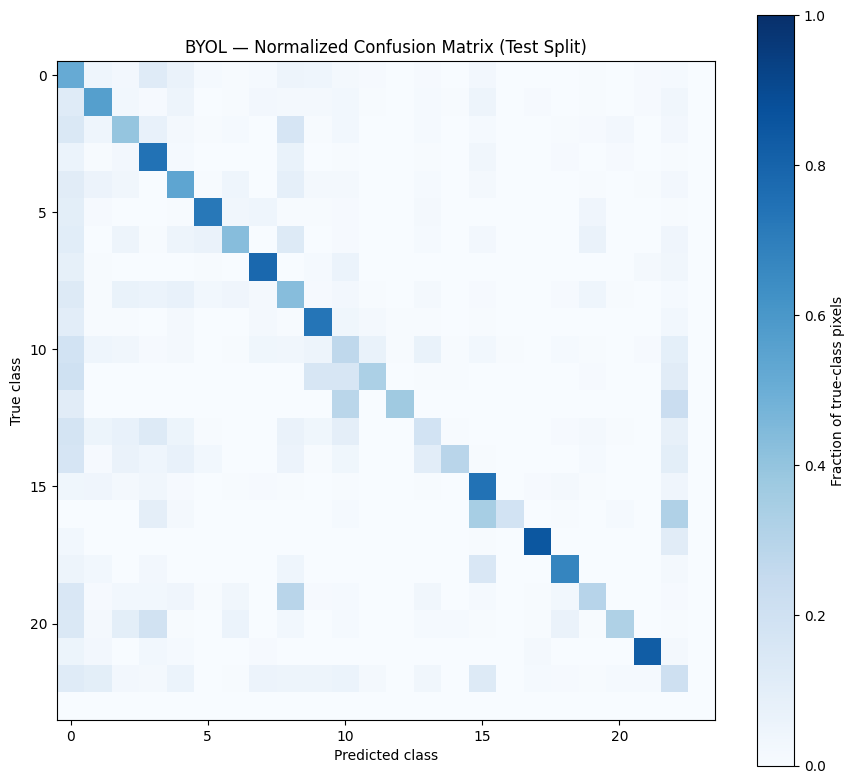

In [19]:
plt.figure(figsize=(9, 8))
cm_normalized = confusion_matrix.float() / (confusion_matrix.sum(dim=1, keepdim=True) + 1e-8)
plt.imshow(cm_normalized.numpy(), cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="Fraction of true-class pixels")
plt.xlabel("Predicted class"); plt.ylabel("True class")
plt.title(f"{CONFIG['method']} — Normalized Confusion Matrix (Test Split)")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## Save Task E results

In [20]:
results = {
    "method": CONFIG["method"],
    "freeze_encoder": CONFIG["freeze_encoder"],
    "num_test_images": len(test_df),
    "num_labelled_finetune_images": len(valid_df),
    "test_mIoU": final_miou,
    "test_mean_dice": final_dice,
    "test_pixel_accuracy": float(final_pixel_acc),
    "per_class_iou": [None if np.isnan(v) else float(v) for v in final_per_class_iou.numpy()],
    "best_checkpoint_epoch": best_checkpoint["epoch"],
}

with open(f"/kaggle/working/{CONFIG['method'].lower()}_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))


{
  "method": "BYOL",
  "freeze_encoder": true,
  "num_test_images": 60,
  "num_labelled_finetune_images": 60,
  "test_mIoU": 0.24965891242027283,
  "test_mean_dice": 0.3642961382865906,
  "test_pixel_accuracy": 0.5787874460220337,
  "per_class_iou": [
    0.015067731030285358,
    0.5402887463569641,
    0.20172160863876343,
    0.6996565461158752,
    0.3783966302871704,
    0.6183857321739197,
    0.13910481333732605,
    0.28452661633491516,
    0.2590017020702362,
    0.5718408226966858,
    0.1359013170003891,
    0.13758468627929688,
    0.07734411954879761,
    0.06721709668636322,
    0.040996696799993515,
    0.17730335891246796,
    0.029129069298505783,
    0.45115357637405396,
    0.14741426706314087,
    0.18056462705135345,
    0.24522309005260468,
    0.2135881781578064,
    0.13074417412281036,
    null
  ],
  "best_checkpoint_epoch": 50
}


---
# Task F — Error Analysis

In [21]:
per_image_df = pd.DataFrame(per_image_records).sort_values("iou")
worst_n = per_image_df.head(6)

print("Worst-performing test images (lowest IoU):")
print(worst_n[["image_path", "iou"]].to_string(index=False))


Worst-performing test images (lowest IoU):
                                                                                                      image_path      iou
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/381.jpg 0.073767
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/543.jpg 0.087707
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/124.jpg 0.091263
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/572.jpg 0.102257
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/564.jpg 0.105227
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/188.jpg 0.110324


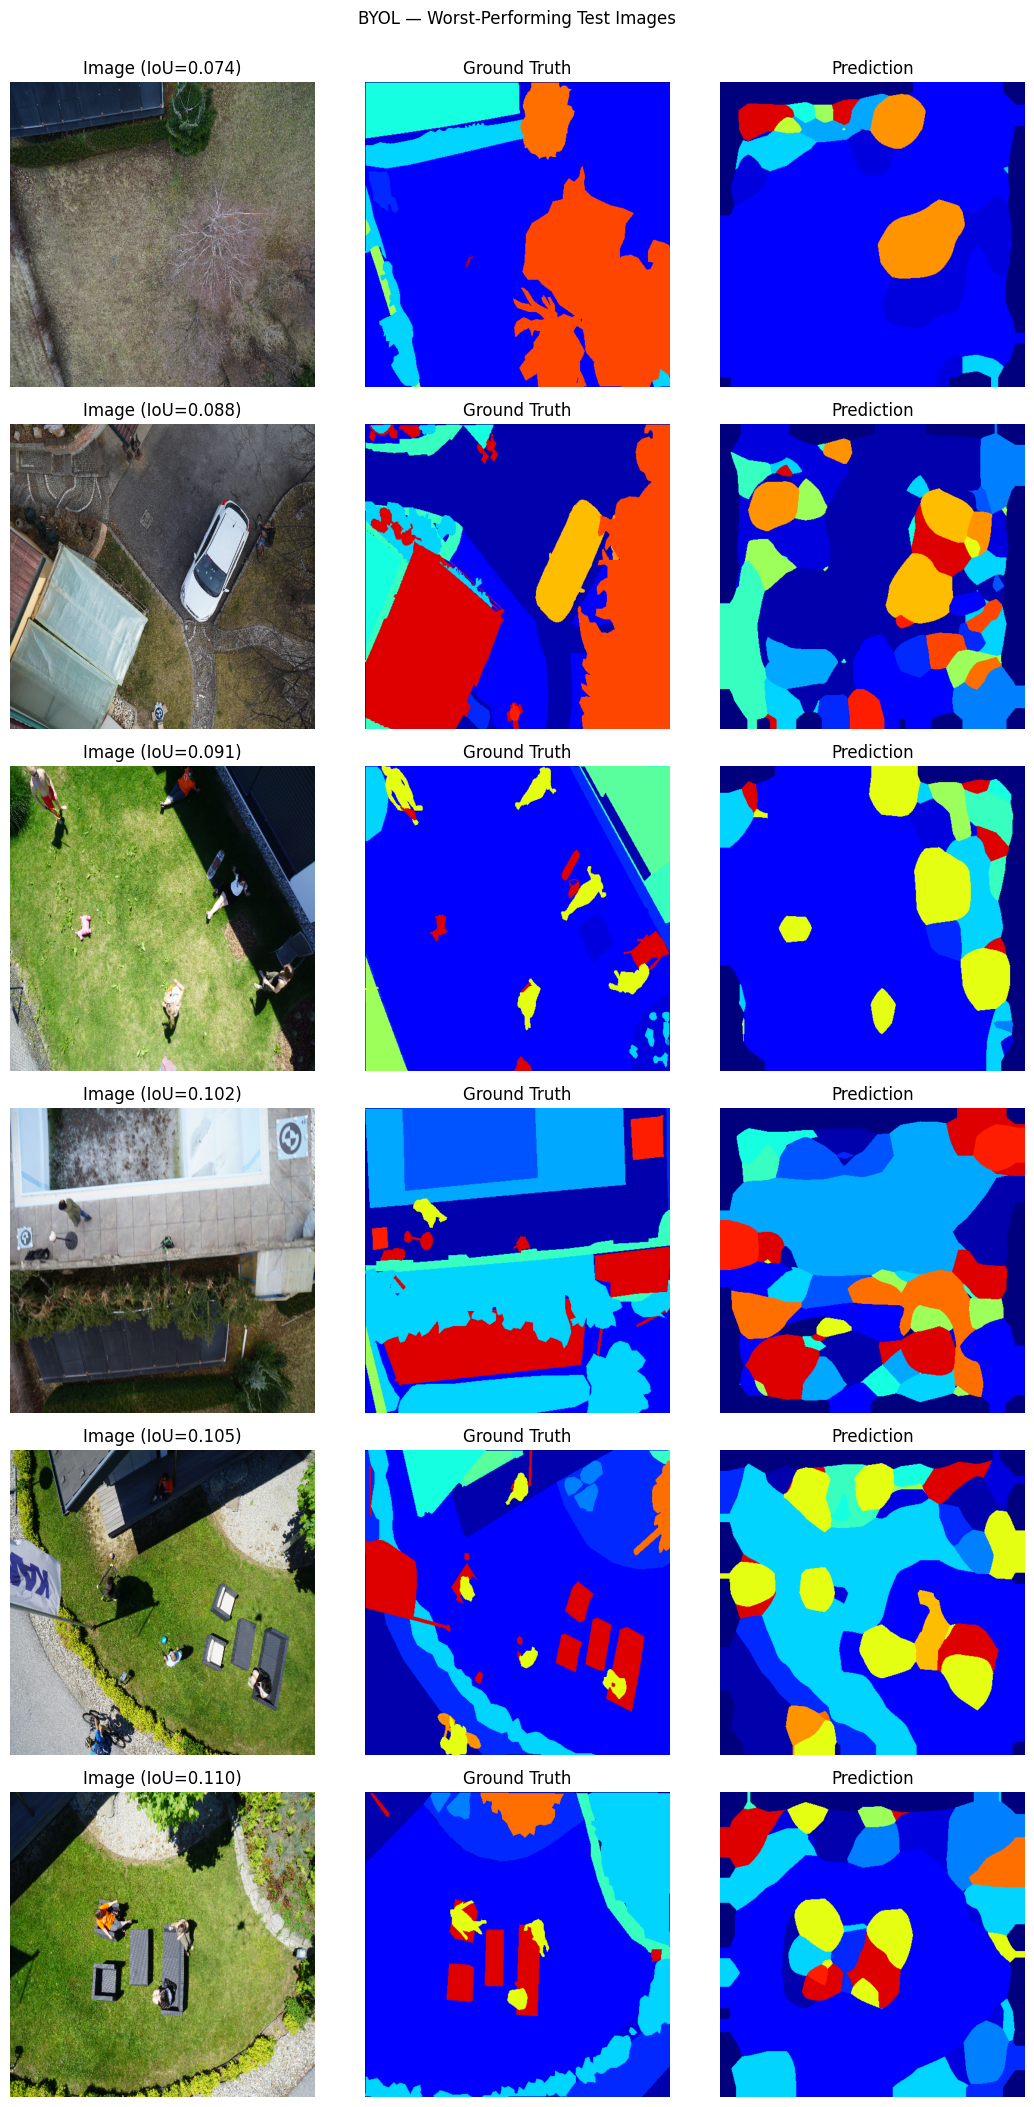

In [22]:
def load_and_predict(image_path, mask_path, model, transform, device):
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    out = transform(image=image, mask=mask)
    img_tensor, gt_mask = out["image"], out["mask"]

    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu()

    def denorm(t):
        mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
        std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
        return np.clip(t.numpy() * std + mean, 0, 1).transpose(1, 2, 0)

    return denorm(img_tensor), gt_mask.numpy(), pred_mask.numpy()


fig, axes = plt.subplots(len(worst_n), 3, figsize=(11, 3.5 * len(worst_n)))

for row_idx, (_, row) in enumerate(worst_n.iterrows()):
    img, gt, pred = load_and_predict(row["image_path"], row["mask_path"], model, eval_transform, DEVICE)

    axes[row_idx, 0].imshow(img); axes[row_idx, 0].set_title(f"Image (IoU={row['iou']:.3f})"); axes[row_idx, 0].axis("off")
    axes[row_idx, 1].imshow(gt, cmap="jet", vmin=0, vmax=num_classes); axes[row_idx, 1].set_title("Ground Truth"); axes[row_idx, 1].axis("off")
    axes[row_idx, 2].imshow(pred, cmap="jet", vmin=0, vmax=num_classes); axes[row_idx, 2].set_title("Prediction"); axes[row_idx, 2].axis("off")

plt.suptitle(f"{CONFIG['method']} — Worst-Performing Test Images", y=1.001)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## Which classes dominate the errors on these worst images?



In [23]:
error_class_counts = Counter()
for _, row in worst_n.iterrows():
    _, gt, pred = load_and_predict(row["image_path"], row["mask_path"], model, eval_transform, DEVICE)
    wrong_pixels_mask = (gt != pred)
    wrong_true_classes = gt[wrong_pixels_mask]
    for c in np.unique(wrong_true_classes):
        error_class_counts[int(c)] += int((wrong_true_classes == c).sum())

print(f"{CONFIG['method']} — pixel error counts by TRUE class, across worst-{len(worst_n)} images:")
for cls, count in sorted(error_class_counts.items(), key=lambda x: -x[1]):
    print(f"  Class {cls}: {count} misclassified pixels")

print("\nUse this to discuss in Section 6.7: does this method's error concentrate on the")
print("same classes as Part A's supervised baseline, or different ones? Why might that be")
print("(e.g. SSL encoders transferring texture/shape priors differently than a purely")
print("supervised backbone)?")


BYOL — pixel error counts by TRUE class, across worst-6 images:
  Class 3: 208401 misclassified pixels
  Class 8: 124487 misclassified pixels
  Class 1: 116747 misclassified pixels
  Class 20: 115737 misclassified pixels
  Class 22: 100518 misclassified pixels
  Class 4: 54562 misclassified pixels
  Class 9: 34172 misclassified pixels
  Class 10: 25859 misclassified pixels
  Class 5: 19001 misclassified pixels
  Class 19: 18952 misclassified pixels
  Class 11: 17182 misclassified pixels
  Class 7: 14869 misclassified pixels
  Class 2: 11800 misclassified pixels
  Class 13: 9992 misclassified pixels
  Class 15: 5170 misclassified pixels
  Class 6: 4856 misclassified pixels
  Class 17: 3537 misclassified pixels
  Class 0: 1637 misclassified pixels
  Class 21: 770 misclassified pixels
  Class 18: 581 misclassified pixels
  Class 14: 69 misclassified pixels

Use this to discuss in Section 6.7: does this method's error concentrate on the
same classes as Part A's supervised baseline, or diff


# Representation Diagnostics — Pair Similarity & t-SNE


In [24]:
from sklearn.manifold import TSNE
import torchvision.transforms as T
from PIL import Image

def get_pooled_embedding(model, x):
    """Global-average-pool the encoder's feature map -> a single vector per image.
    Works identically for CNN (SimCLR/BYOL) and ViT (MAE/DINOv2) encoders here,
    since Task C already unified their output to [B, C, H, W]."""
    with torch.no_grad():
        feat = model.encoder(x)          # [B, C, H, W]
        emb = feat.mean(dim=[2, 3])        # [B, C]
    return emb


## t-SNE of encoder embeddings, colored by ground-truth majority class


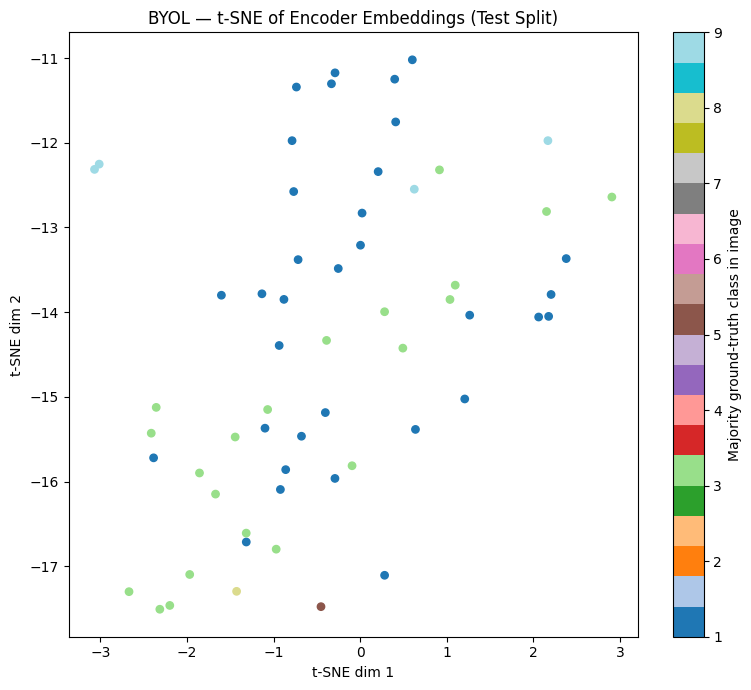

In [25]:
N_TSNE_SAMPLES = min(200, len(test_df))
tsne_sample_df = test_df.sample(N_TSNE_SAMPLES, random_state=42).reset_index(drop=True)

embeddings, majority_classes = [], []
model.eval()

for _, row in tsne_sample_df.iterrows():
    image = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    out = eval_transform(image=image, mask=mask)
    img_tensor = out["image"].unsqueeze(0).to(DEVICE)

    emb = get_pooled_embedding(model, img_tensor)
    embeddings.append(emb.cpu().numpy().squeeze())

    vals, counts = np.unique(out["mask"].numpy(), return_counts=True)
    majority_classes.append(int(vals[np.argmax(counts)]))   # dominant class in this image's mask

embeddings = np.stack(embeddings)
majority_classes = np.array(majority_classes)

tsne = TSNE(n_components=2, perplexity=min(30, N_TSNE_SAMPLES - 1), random_state=42, init="pca")
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=majority_classes, cmap="tab20", s=28)
plt.colorbar(scatter, label="Majority ground-truth class in image")
plt.title(f"{CONFIG['method']} — t-SNE of Encoder Embeddings (Test Split)")
plt.xlabel("t-SNE dim 1"); plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_tsne.png", dpi=150, bbox_inches="tight")
plt.show()


## Pair-similarity check 

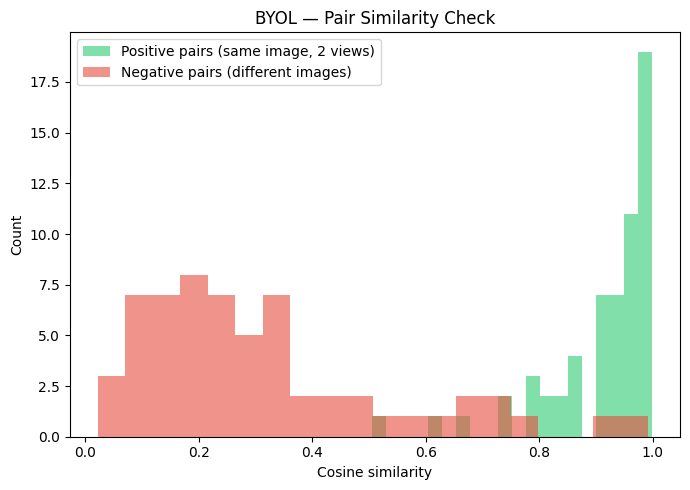

Mean positive-pair similarity: 0.9129
Mean negative-pair similarity: 0.3094
Gap: 0.6034

A clear positive-vs-negative gap here is representation-level evidence
that the pretext task worked -- independent of, and complementary to,
the downstream mIoU/Dice numbers already reported in Task E.


In [26]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

pair_transform = T.Compose([
    T.RandomResizedCrop(CONFIG["image_size"], scale=(0.4, 1.0)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

N_PAIR_SAMPLES = min(64, len(test_df))
pair_sample_df = test_df.sample(N_PAIR_SAMPLES, random_state=42).reset_index(drop=True)

view1_embs, view2_embs = [], []
for _, row in pair_sample_df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    v1 = pair_transform(img).unsqueeze(0).to(DEVICE)
    v2 = pair_transform(img).unsqueeze(0).to(DEVICE)
    view1_embs.append(get_pooled_embedding(model, v1).cpu().numpy().squeeze())
    view2_embs.append(get_pooled_embedding(model, v2).cpu().numpy().squeeze())

view1_embs = np.stack(view1_embs)
view2_embs = np.stack(view2_embs)

def cosine_sim(a, b):
    return np.sum(a * b, axis=-1) / (np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1) + 1e-8)

positive_sims = cosine_sim(view1_embs, view2_embs)

rng = np.random.default_rng(42)
shuffled_view2 = view2_embs[rng.permutation(len(view2_embs))]
negative_sims = cosine_sim(view1_embs, shuffled_view2)

plt.figure(figsize=(7, 5))
plt.hist(positive_sims, bins=20, alpha=0.6, label="Positive pairs (same image, 2 views)", color="#2ecc71")
plt.hist(negative_sims, bins=20, alpha=0.6, label="Negative pairs (different images)", color="#e74c3c")
plt.xlabel("Cosine similarity"); plt.ylabel("Count")
plt.title(f"{CONFIG['method']} — Pair Similarity Check")
plt.legend()
plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_pair_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean positive-pair similarity: {positive_sims.mean():.4f}")
print(f"Mean negative-pair similarity: {negative_sims.mean():.4f}")
print(f"Gap: {positive_sims.mean() - negative_sims.mean():.4f}")
print("\nA clear positive-vs-negative gap here is representation-level evidence")
print("that the pretext task worked -- independent of, and complementary to,")
print("the downstream mIoU/Dice numbers already reported in Task E.")


## Save diagnostic summary

In [27]:
diagnostic_summary = {
    "method": CONFIG["method"],
    "mean_positive_pair_similarity": float(positive_sims.mean()),
    "mean_negative_pair_similarity": float(negative_sims.mean()),
    "similarity_gap": float(positive_sims.mean() - negative_sims.mean()),
    "tsne_samples": N_TSNE_SAMPLES,
    "pair_samples": N_PAIR_SAMPLES,
}

with open(f"/kaggle/working/{CONFIG['method'].lower()}_diagnostics.json", "w") as f:
    json.dump(diagnostic_summary, f, indent=2)

print(json.dumps(diagnostic_summary, indent=2))


{
  "method": "BYOL",
  "mean_positive_pair_similarity": 0.9128705263137817,
  "mean_negative_pair_similarity": 0.3094281554222107,
  "similarity_gap": 0.603442370891571,
  "tsne_samples": 60,
  "pair_samples": 60
}
